In [1]:
import torch
import os
from utilities import *
device = torch.device('xpu')
print(device)

xpu


c:\Users\runan\kan-robustness-scaling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
# Parameters

ranges = [-1, 1]
n_train = 1000
n_test = 1000
steps = 200
grids = [3, 5, 10, 20, 50, 100]
k=3
lr=1
dimensions = [5, 10, 20, 50, 100, 200, 500, 1000]
seeds = [0, 1, 42]

In [15]:
def train_all_seeds(data):
    static_kan = {}
    dyn_kan = {}
    mlp = {}

    for seed in seeds:
        
        static_kan_results = {}
        dyn_kan_results = {}
        mlp_results = {}
        
        for d in dimensions:
            dataset_path = os.path.join("datasets", f'seed {seed}', f'{data}_dataset_dim{d}_seed{seed}.pt')
            if os.path.exists(dataset_path):
                dataset = torch.load(dataset_path, map_location='cpu')
            else:
                dataset = generate_dataset(d, data, seed, n_train, n_test, device=torch.device('cpu'), ranges=ranges)
            width = [d, 1, 1]
            kan_param = (width[0] * width[1] * (grids[0] + k + 3) + width[1]) + (width[1] * width[2] * (grids[0] + k + 3) + width[2])
            mlp_hidden_width = math.ceil((10*d+11)/(d+2)) - 1

            static_kan_results[d] = train_kan(width=width, dataset=dataset, static=True, seed=seed, steps=steps,grids=grids, lr=lr, k=k)
            dyn_kan_results[d] = train_kan(width=width, dataset=dataset, static=False, seed=seed, steps=steps, grids=grids, lr=lr, k=k)
            mlp_results[d] = train_mlp(width=[d, mlp_hidden_width, 1], dataset=dataset, seed=seed, steps=steps, lr=lr)
            mlp_param = mlp_results[d]['param_counts']
            print(f"Dimension {d}: KAN params: {kan_param}, MLP params: {mlp_param}")
        
        static_kan[seed] = static_kan_results
        dyn_kan[seed] = dyn_kan_results
        mlp[seed] = mlp_results
    
        output_dir = os.path.join("3-results", f'{steps}-epochs-seed-{seed}')
        os.makedirs(output_dir, exist_ok=True)
        torch.save(static_kan, os.path.join(output_dir, f'static_kan_{data}.pt'))
        torch.save(dyn_kan, os.path.join(output_dir, f'dyn_kan_{data}.pt'))
        torch.save(mlp, os.path.join(output_dir, f'mlp_{data}.pt'))
    return static_kan, dyn_kan, mlp


In [ ]:
static_kan_A, dyn_kan_A, mlp_A = train_all_seeds('A')

In [16]:
static_kan_B, dyn_kan_B, mlp_B = train_all_seeds('B')

Grid=3:   0%|          | 0/200 [00:00<?, ?it/s]

| train_loss: 1.25e-02 | test_loss: 1.40e-02 | reg: 3.04e+01 | : 100%|█| 200/200 [00:08<00:00, 23.80


Dimension 5: KAN params: 56, MLP params: 57


| train_loss: 5.29e-02 | test_loss: 6.77e-02 | reg: 5.04e+01 | : 100%|█| 200/200 [00:08<00:00, 22.98


Dimension 10: KAN params: 101, MLP params: 109


...

Dimension 200: KAN params: 1811, MLP params: 1819


| train_loss: 1.09e-07 | test_loss: 1.98e-01 | reg: 3.52e+02 | : 100%|█| 200/200 [00:16<00:00, 12.17


Dimension 500: KAN params: 4511, MLP params: 4519


| train_loss: 2.41e-08 | test_loss: 2.04e-01 | reg: 2.16e+02 | : 100%|█| 200/200 [00:25<00:00,  7.77


Dimension 1000: KAN params: 9011, MLP params: 9019


In [19]:
static_kan_C, dyn_kan_C, mlp_C = train_all_seeds('C')

Grid=3:   0%|          | 0/200 [00:00<?, ?it/s]

| train_loss: 3.17e-05 | test_loss: 3.50e-05 | reg: 2.49e+01 | : 100%|█| 200/200 [00:19<00:00, 10.21


Dimension 5: KAN params: 56, MLP params: 57


| train_loss: 1.65e-05 | test_loss: 1.85e-05 | reg: 3.81e+01 | : 100%|█| 200/200 [00:16<00:00, 12.23


Dimension 10: KAN params: 101, MLP params: 109


...

Dimension 200: KAN params: 1811, MLP params: 1819


| train_loss: 9.94e-08 | test_loss: 8.64e-02 | reg: 2.03e+02 | : 100%|█| 200/200 [00:21<00:00,  9.52


Dimension 500: KAN params: 4511, MLP params: 4519


| train_loss: 6.72e-08 | test_loss: 2.97e-01 | reg: 2.25e+02 | : 100%|█| 200/200 [00:20<00:00,  9.80


Dimension 1000: KAN params: 9011, MLP params: 9019


In [20]:
def plot_r2s_rmses_all(static_list, dyn_list, mlp_list, dimensions, seeds, labels, plot_mlp=True, cutoff = 3):
    n = len(labels)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 8), sharex='col')
    if n == 1:
        axes = np.array([[axes[0]],[axes[1]]])

    def mean_err(results_all_seeds, dimensions, seeds, key):
        means = []
        lower_errs = []
        upper_errs = []
        for d in dimensions:
            final_vals = np.array([results_all_seeds[seed][d][key][-1] for seed in seeds])
            mean_val = np.mean(final_vals)
            min_val = np.min(final_vals)
            max_val = np.max(final_vals)
            means.append(mean_val)
            lower_errs.append(mean_val - min_val)
            upper_errs.append(max_val - mean_val)
        return np.array(means), np.vstack([lower_errs, upper_errs])

    for i, lab in enumerate(labels):
        static_kan = static_list[i]
        dyn_kan = dyn_list[i]
        mlp = mlp_list[i]
        static_means_r2, static_yerr_r2 = mean_err(static_kan, dimensions, seeds, 'r2s')
        dyn_means_r2, dyn_yerr_r2 = mean_err(dyn_kan, dimensions, seeds, 'r2s')
        mlp_means_r2, mlp_yerr_r2 = mean_err(mlp, dimensions, seeds, 'r2s')
        static_means_rmse, static_yerr_rmse = mean_err(static_kan, dimensions, seeds, 'rmses')
        dyn_means_rmse, dyn_yerr_rmse = mean_err(dyn_kan, dimensions, seeds, 'rmses')
        mlp_means_rmse, mlp_yerr_rmse = mean_err(mlp, dimensions, seeds, 'test_loss')

        ax_rmse = axes[0, i]
        ax_r2 = axes[1, i]

        ax_rmse.errorbar(dimensions, static_means_rmse, yerr=static_yerr_rmse, marker='s', linestyle='-', capsize=4, elinewidth=1.5, alpha=0.8, label='Static KAN')
        ax_rmse.errorbar(dimensions, dyn_means_rmse, yerr=dyn_yerr_rmse, marker='^', linestyle='-', capsize=4, elinewidth=1.5, alpha=0.8, label='Dynamic KAN')
        if plot_mlp:
            ax_rmse.errorbar(dimensions, mlp_means_rmse, yerr=mlp_yerr_rmse, marker='o', linestyle='-', capsize=4, elinewidth=1.5, alpha=0.8, label='MLP')

        ax_r2.errorbar(dimensions, static_means_r2, yerr=static_yerr_r2, marker='s', linestyle='-', capsize=4, elinewidth=1.5, alpha=0.8)
        ax_r2.errorbar(dimensions, dyn_means_r2, yerr=dyn_yerr_r2, marker='^', linestyle='-', capsize=4, elinewidth=1.5, alpha=0.8)
        if plot_mlp:
            ax_r2.errorbar(dimensions, mlp_means_r2, yerr=mlp_yerr_r2, marker='o', linestyle='-', capsize=4, elinewidth=1.5, alpha=0.8)

        ax_rmse.set_xscale('log')
        # ax_rmse.set_xlabel('dimensions (log)')
        ax_rmse.set_xticks(dimensions)
        ax_rmse.set_xticklabels(dimensions)
        ax_rmse.set_yscale('log')
        ax_r2.set_xscale('log')

        ax_r2.set_xlabel('dimensions (log)')
        ax_r2.set_xticks(dimensions)
        ax_r2.set_xticklabels(dimensions)
        ax_r2.set_yscale('symlog')
        if cutoff < len(dimensions):
            ax_r2.axvline(x=dimensions[cutoff], color='red', linestyle='--', alpha=0.6)
        ax_rmse.set_title(f'Dataset {lab}')

        # --- AUTOMATIC Y-AXIS SCALE GENERATION FOR R2 (limit to 1) ---
        lowest_allowed = min(
            np.min(static_means_r2 - static_yerr_r2[0]),
            np.min(dyn_means_r2 - dyn_yerr_r2[0]),
            np.min(mlp_means_r2 - mlp_yerr_r2[0]) if plot_mlp else np.min(static_means_r2 - static_yerr_r2[0])
        )

        custom_ticks = []
        custom_labels = []
        auto_ymin = -1.0

        if lowest_allowed < 0:
            max_power = int(np.ceil(np.log10(abs(lowest_allowed))))
            auto_ymin = -(10**max_power) * 1.1
            for p in range(max_power, -1, -1):
                custom_ticks.append(-(10**p))
                custom_labels.append(f"$-10^{p}$")

        # always include 0 and 1; display '1' instead of '10^0'
        custom_ticks.extend([0, 1])
        custom_labels.extend(["0", "1"]) 

        ax_r2.set_ylim(auto_ymin, 1.3)
        ax_r2.set_yticks(custom_ticks)
        ax_r2.set_yticklabels(custom_labels)

        # Only label leftmost y-axes
        if i == 0:
            ax_rmse.set_ylabel('RMSE (log)')
            ax_r2.set_ylabel('R2 Score')
        else:
            ax_rmse.set_ylabel('')
            ax_r2.set_ylabel('')

    # Single shared legend (use handles from top-left axis)
    handles, labels_ = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)
    plt.suptitle('KAN vs MLP (RMSE top, R2 bottom)')
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig(f"3-result-multi-{'_'.join(labels)}.png", bbox_inches='tight', dpi=300)
    plt.show()


In [27]:
def load_all_results(steps, data_types=['A', 'B', 'C']):
  
    results = {}
    results_dir = "3-results"
    seed_dirs = []
    
    for item in os.listdir(results_dir):
        if f'{steps}-epochs-seed-' in item:
            seed_dirs.append(item)
    
    seed_dirs.sort()
    
    for data_type in data_types:
        static_kan_all = {}
        dyn_kan_all = {}
        mlp_all = {}
        
        for seed_dir in seed_dirs:
            seed = int(seed_dir.split('-')[-1])
            
            dir_path = os.path.join(results_dir, seed_dir)
            static_path = os.path.join(dir_path, f'static_kan_{data_type}.pt')
            dyn_path = os.path.join(dir_path, f'dyn_kan_{data_type}.pt')
            mlp_path = os.path.join(dir_path, f'mlp_{data_type}.pt')
            
            if os.path.exists(static_path):
                static_kan_all.update(torch.load(static_path, weights_only=False))
                print(f"Loaded Static KAN {data_type} from seed {seed}")
            if os.path.exists(dyn_path):
                dyn_kan_all.update(torch.load(dyn_path, weights_only=False))
                print(f"Loaded Dynamic KAN {data_type} from seed {seed}")
            if os.path.exists(mlp_path):
                mlp_all.update(torch.load(mlp_path, weights_only=False))
                print(f"Loaded MLP {data_type} from seed {seed}")
        
        results[data_type] = {
            'static_kan': static_kan_all,
            'dyn_kan': dyn_kan_all,
            'mlp': mlp_all
        }
    
    return results

# Load results from 200-epoch training
results = load_all_results(200, ['A', 'B', 'C'])


Loaded Static KAN A from seed 0
Loaded Dynamic KAN A from seed 0
Loaded MLP A from seed 0
Loaded Static KAN A from seed 1
Loaded Dynamic KAN A from seed 1
Loaded MLP A from seed 1
Loaded Static KAN A from seed 42
Loaded Dynamic KAN A from seed 42
Loaded MLP A from seed 42
Loaded Static KAN A from seed 0
Loaded Dynamic KAN A from seed 0
Loaded MLP A from seed 0
Loaded Static KAN A from seed 1
Loaded Dynamic KAN A from seed 1
Loaded MLP A from seed 1
Loaded Static KAN A from seed 42
Loaded Dynamic KAN A from seed 42
Loaded MLP A from seed 42
Loaded Static KAN B from seed 0
Loaded Dynamic KAN B from seed 0
Loaded MLP B from seed 0
Loaded Static KAN B from seed 1
Loaded Dynamic KAN B from seed 1
Loaded Static KAN B from seed 0
Loaded Dynamic KAN B from seed 0
Loaded MLP B from seed 0
Loaded Static KAN B from seed 1
Loaded Dynamic KAN B from seed 1
Loaded MLP B from seed 1
Loaded Static KAN B from seed 42
Loaded Dynamic KAN B from seed 42
Loaded MLP B from seed 42
Loaded Static KAN C from s

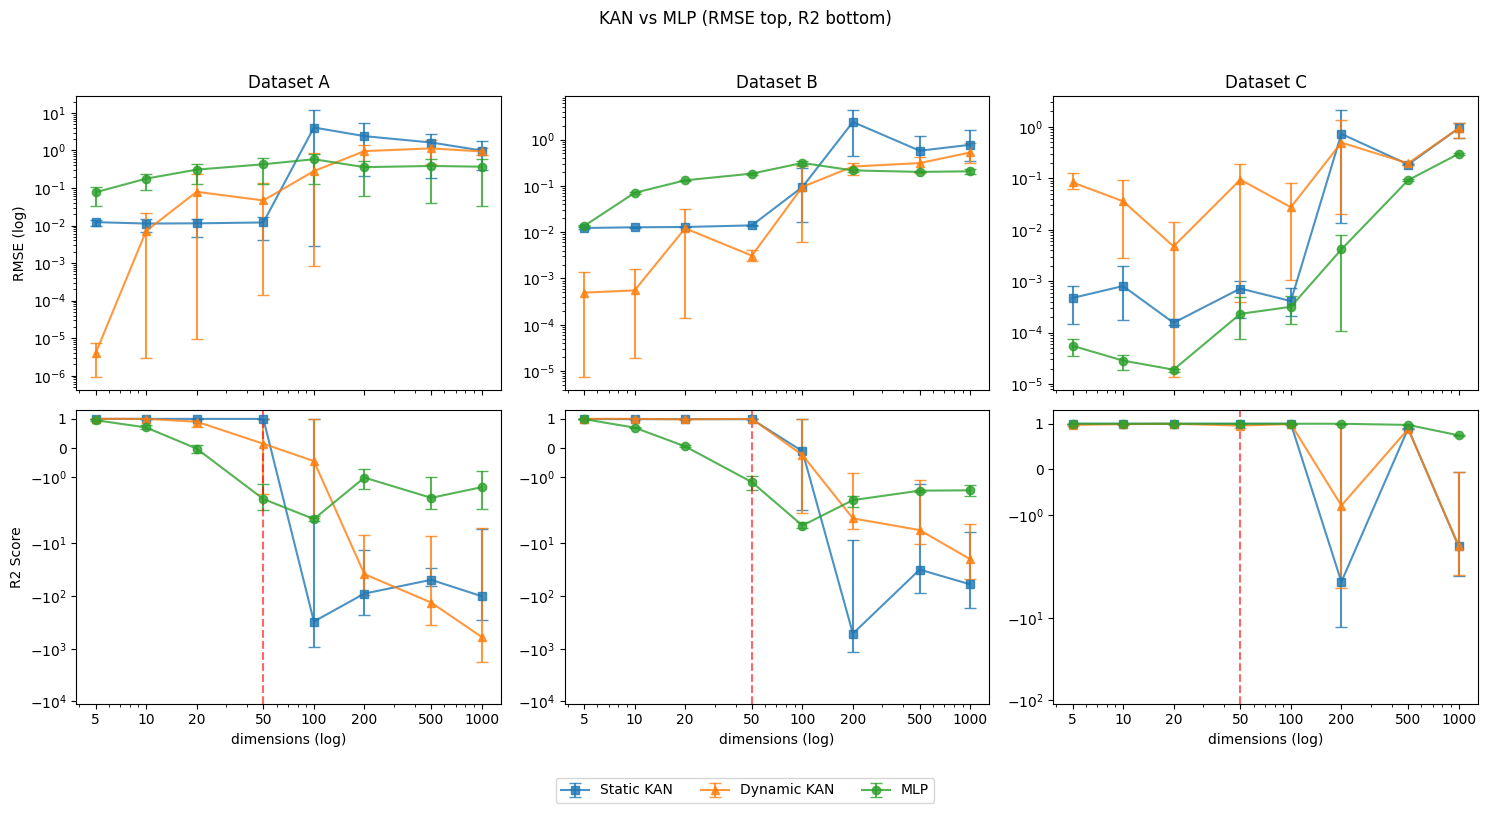

In [28]:
plot_r2s_rmses_all(
    [results['A']['static_kan'], results['B']['static_kan'], results['C']['static_kan']],
    [results['A']['dyn_kan'], results['B']['dyn_kan'], results['C']['dyn_kan']],
    [results['A']['mlp'], results['B']['mlp'], results['C']['mlp']],
    dimensions,
    seeds,
    ['A', 'B', 'C'],
    plot_mlp=True,
    cutoff=3
)
